In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

In [2]:
# TODO: change name if needed
name = "Mrk501"
blazar_coord = SkyCoord.from_name(name)
# TODO: change data_folder if needed
data_folder = "../cta_dc_data/mrk_501/"
data_folder_40deg = data_folder+"40deg/"
data_folder_20deg = data_folder+"20deg/"
irf_file_40deg = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irf_file_20deg = "../cta_dc_data/irfs/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus_40deg = []
hbus_20deg = []
for filename in os.listdir(data_folder_40deg):
    hbus_40deg.append(fits.open(data_folder_40deg + filename))
for filename in os.listdir(data_folder_20deg):
    hbus_20deg.append(fits.open(data_folder_20deg + filename))
    
irf_40deg = load_irf_dict_from_file(irf_file_40deg)
irf_20deg = load_irf_dict_from_file(irf_file_20deg)
print(f"Pointings 40deg: {len(hbus_40deg)}")
print(f"Pointings 20deg: {len(hbus_20deg)}")

Pointings 40deg: 60
Pointings 20deg: 66


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

#th2_bins=np.linspace(0,0.16,17)
th2_bins=np.linspace(0,0.16,34)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )
        
        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    return cts_s, cts_b, t_expo

In [6]:
bkg_subtraction_radius = 0.4

cts_s_40deg, cts_b_40deg, t_expo_40deg = collect_data(hbus_40deg)
cts_s_20deg, cts_b_20deg, t_expo_20deg = collect_data(hbus_20deg)

print(f"Exposure time 40deg = {t_expo_40deg/60/60:.1f}h")
print(f"Exposure time 20deg = {t_expo_20deg/60/60:.1f}h")

Exposure time 40deg = 8.5h
Exposure time 20deg = 9.3h


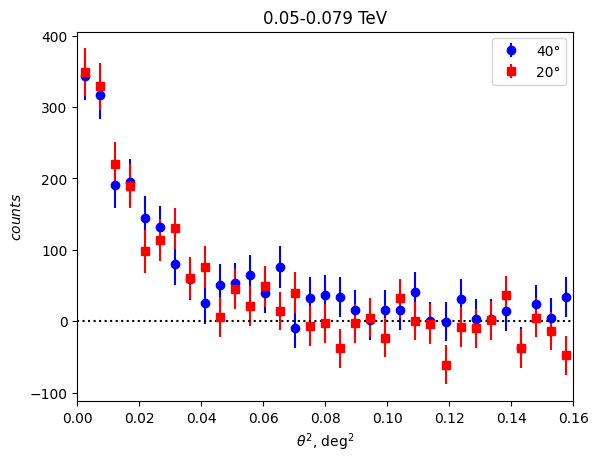

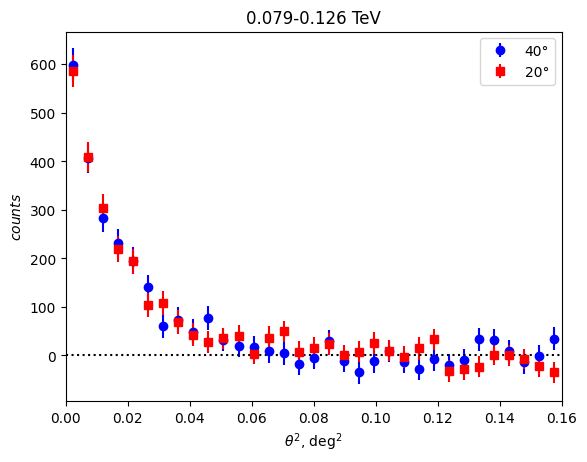

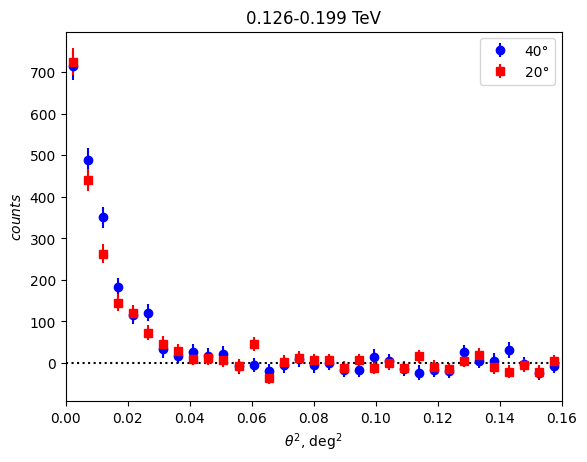

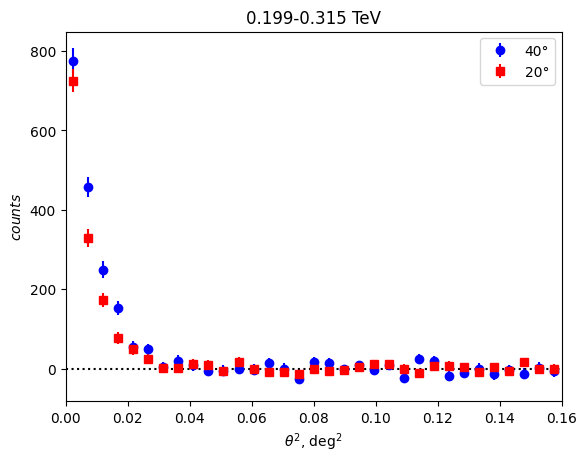

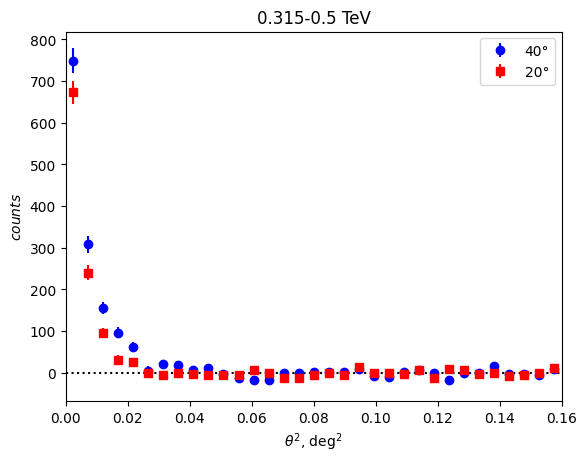

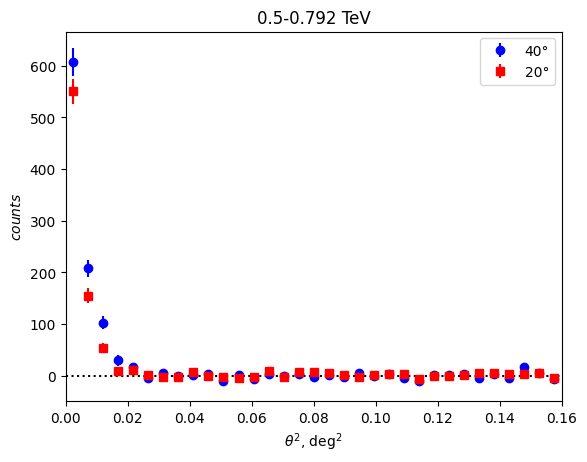

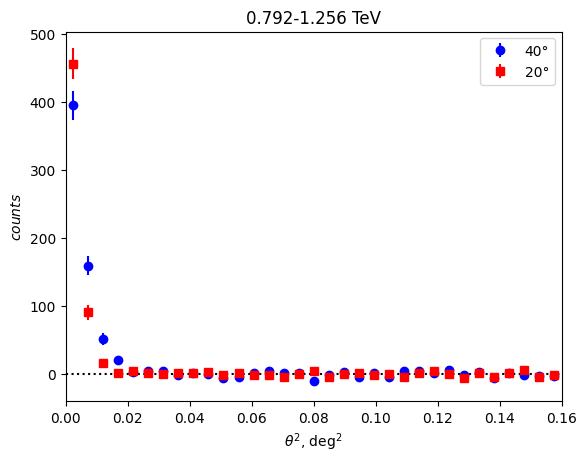

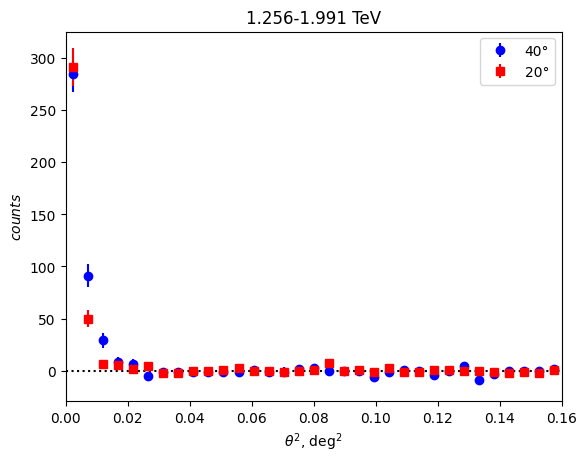

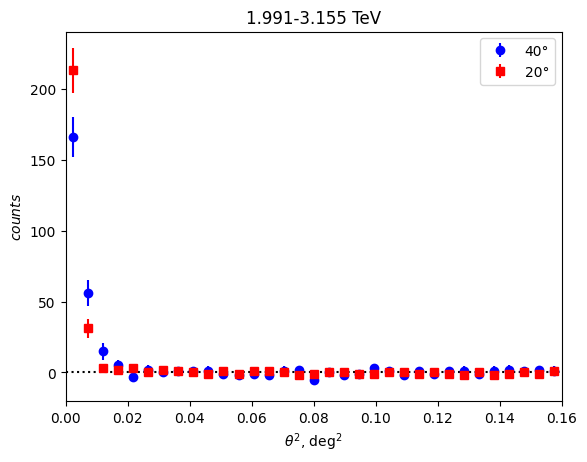

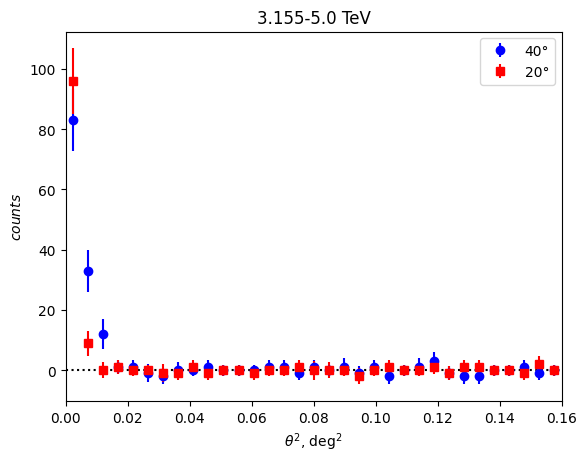

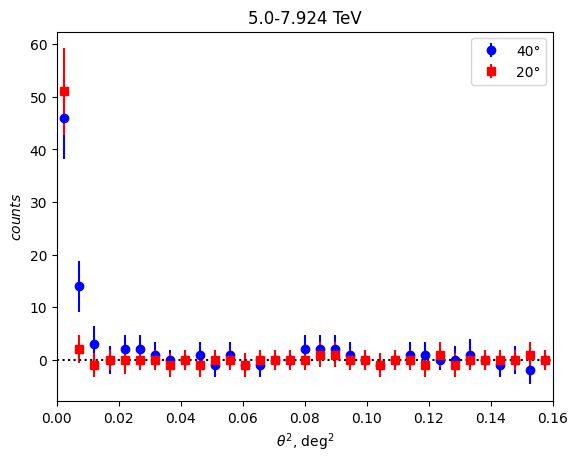

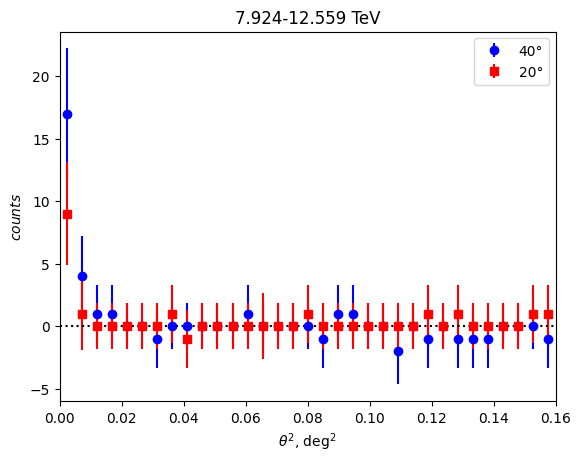

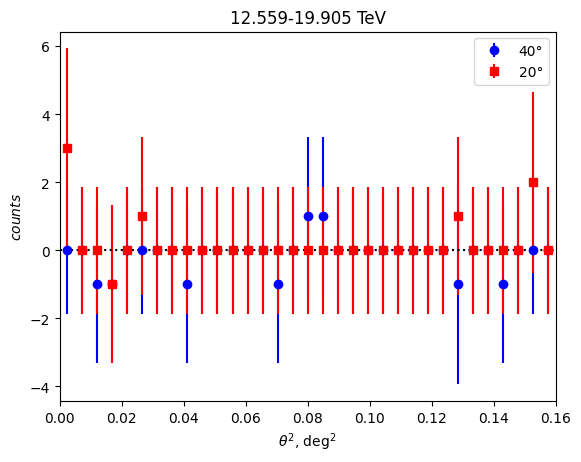

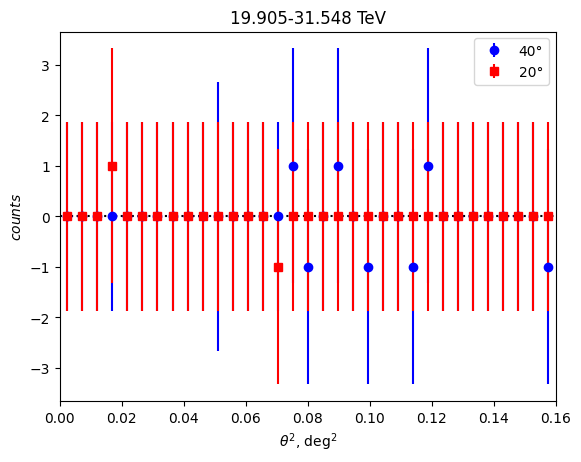

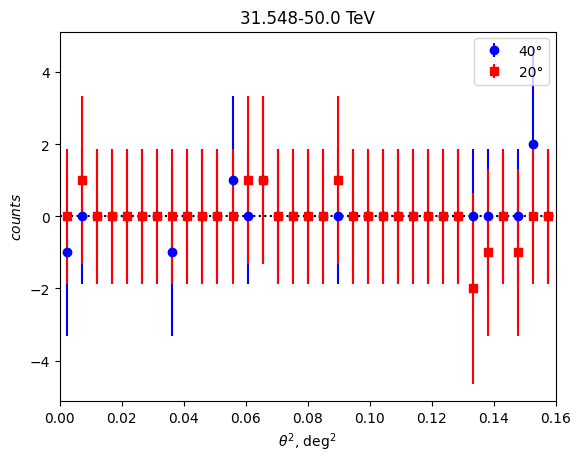

In [7]:
cts_40deg = cts_s_40deg - cts_b_40deg
cts_err_40deg = 1 + np.sqrt(cts_s_40deg + cts_b_40deg + 0.75)

cts_20deg = cts_s_20deg - cts_b_20deg
cts_err_20deg = 1 + np.sqrt(cts_s_20deg + cts_b_20deg + 0.75)

for i, ((cts_40, cts_err_40), (cts_20, cts_err_20)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
    plt.figure()
    plt.errorbar(th2, cts_40, cts_err_40, fmt='o', label='40°', color='blue')
    plt.errorbar(th2, cts_20, cts_err_20, fmt='s', label='20°', color='red')
    plt.axhline(0, color='black', linestyle='dotted')
    plt.xlim(0, 0.16)
    plt.title(str(round(e_mins[i],3)) + '-' + str(round(e_maxs[i],3)) + ' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.legend()
    plt.show()

In [8]:
psf_hbu_40deg = irf_40deg["psf"]
psf_hbu_20deg = irf_20deg["psf"]

print(psf_hbu_40deg)
print(psf_hbu_40deg.info())
print(psf_hbu_40deg.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

In [9]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]

In [10]:
def calculate_UL(cts, cts_err, psf_hbu):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    
    for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]
    
        # Normalization of the PSF model to fit best the blazar
        def psf_model(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1**2))
            gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
            gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
            return (gauss1+gauss2+gauss3)

        # rescaling the psf component to match total counts of the data
        psf_component = psf_model(th2)
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        # psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        # Lets try without error
        psf_component_err = np.zeros_like(psf_component)
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
        
        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                c1 = sigma_1/(sigma_1**2 + sigma_ext**2)
                c2 = ampl_2*sigma_2/(sigma_2**2 + sigma_ext**2)
                c3 = ampl_3*sigma_3/(sigma_3**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv
        
            ct_ext = ext_model(th2)
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            # Here chi2_ext is chi2_min, the best fit possible.
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")

            # Upper limits
            # We fix the extended normalization and keep the other parameters free. delta dof = 1.
            # We finish at chi2 - chi2_min \approx 2.71
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                # extended normalization fixed ...
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                # ... while we fit best with other parameters:
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratios[k][i] = np.sum(ct_ext)/cts_tot_best
            axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

Best fit extended plus point gives chi2: 19.501937404421632
Best fit extended plus point gives chi2: 18.27334923738762
Best fit extended plus point gives chi2: 17.95117283867431
Best fit extended plus point gives chi2: 17.84777221983126


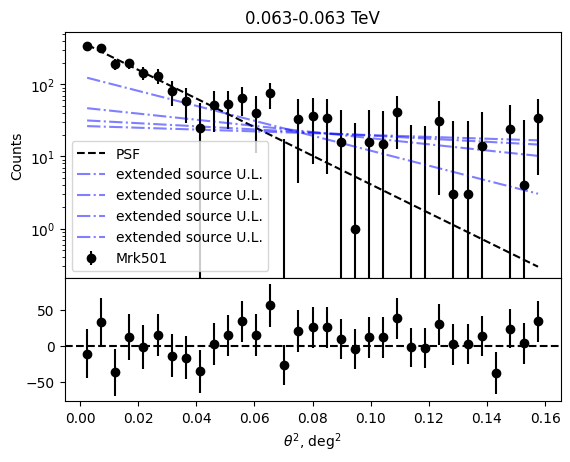

Best fit extended plus point gives chi2: 22.275353335920638
Best fit extended plus point gives chi2: 22.220416433886317
Best fit extended plus point gives chi2: 22.220416433886914
Best fit extended plus point gives chi2: 22.22041643388664


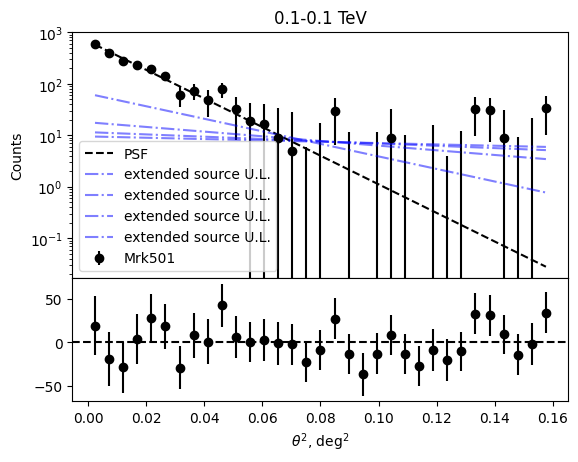

Best fit extended plus point gives chi2: 26.748431421558237
Best fit extended plus point gives chi2: 26.748431421558575
Best fit extended plus point gives chi2: 26.74843142155817
Best fit extended plus point gives chi2: 26.748431421558646


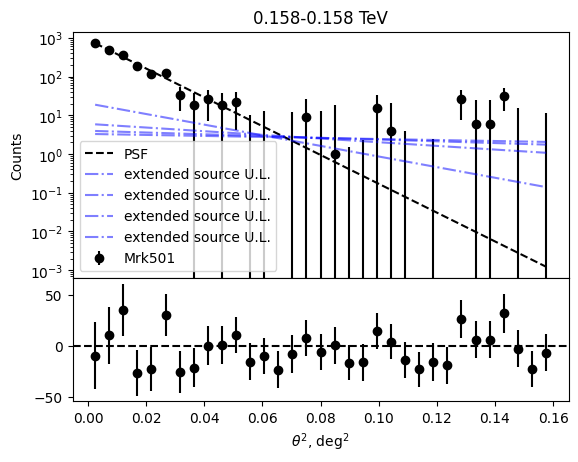

Best fit extended plus point gives chi2: 30.567769517494565
Best fit extended plus point gives chi2: 30.567769517494714
Best fit extended plus point gives chi2: 30.567769517495027
Best fit extended plus point gives chi2: 30.567769517495545


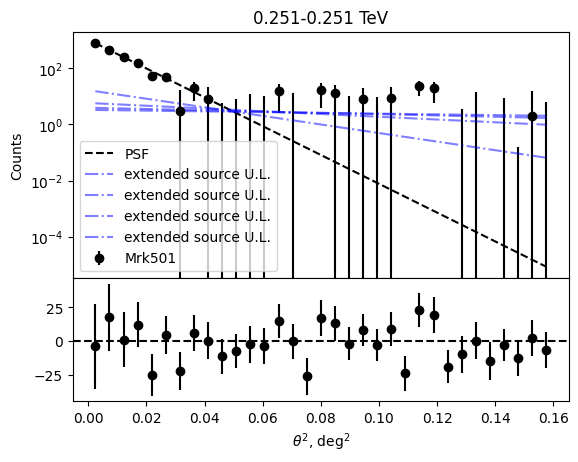

Best fit extended plus point gives chi2: 39.431247077365406
Best fit extended plus point gives chi2: 39.656612527785214
Best fit extended plus point gives chi2: 39.65661252778428
Best fit extended plus point gives chi2: 39.65661252778437


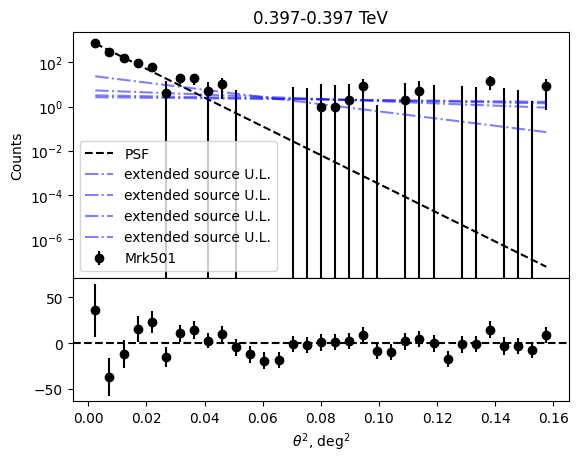

Best fit extended plus point gives chi2: 31.24140105302261
Best fit extended plus point gives chi2: 31.24140105302349
Best fit extended plus point gives chi2: 31.24140105302346
Best fit extended plus point gives chi2: 31.241401053022912


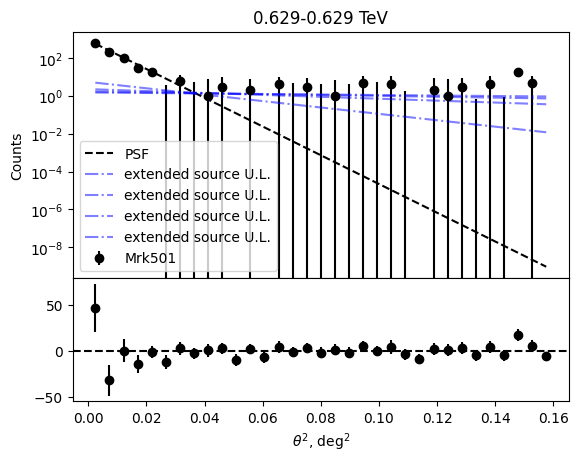

Best fit extended plus point gives chi2: 19.902906899017808
Best fit extended plus point gives chi2: 19.902906899018674
Best fit extended plus point gives chi2: 19.902906899018483
Best fit extended plus point gives chi2: 19.9029068990182


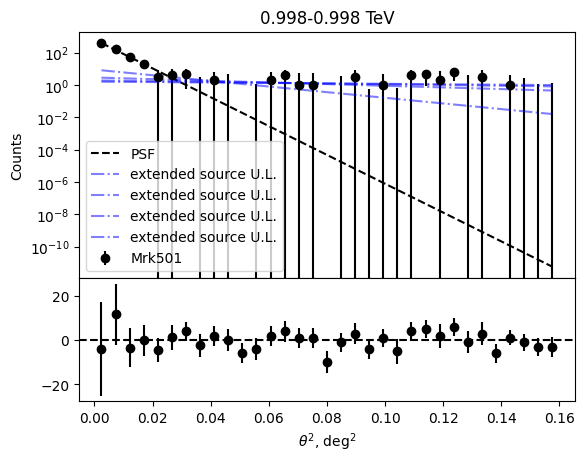

Best fit extended plus point gives chi2: 17.06646035484958
Best fit extended plus point gives chi2: 17.066460354849827
Best fit extended plus point gives chi2: 17.06646035484988
Best fit extended plus point gives chi2: 17.066460354849625


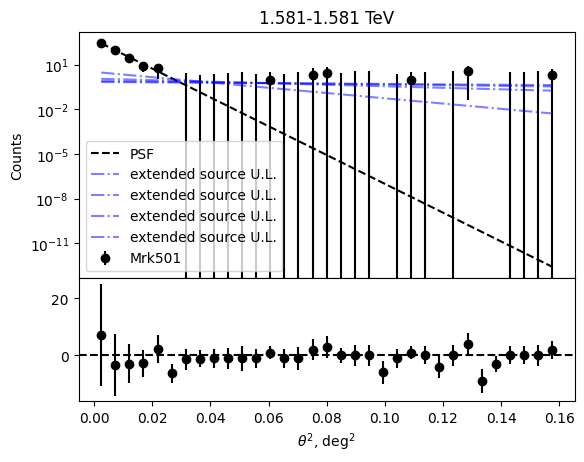

Best fit extended plus point gives chi2: 11.480199958022595
Best fit extended plus point gives chi2: 11.480199958022649
Best fit extended plus point gives chi2: 11.480199958022684
Best fit extended plus point gives chi2: 11.480199958022672


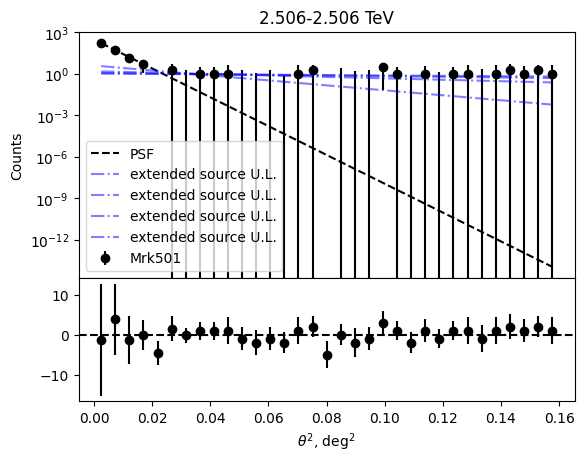

Best fit extended plus point gives chi2: 7.7683658643437425
Best fit extended plus point gives chi2: 7.768365864343684
Best fit extended plus point gives chi2: 7.768365864343728
Best fit extended plus point gives chi2: 7.768365864343696


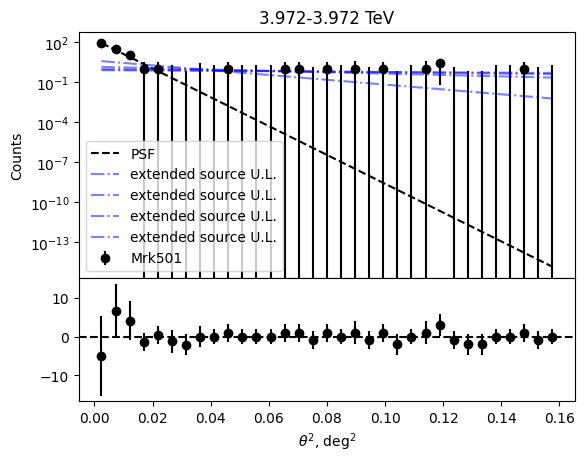

Best fit extended plus point gives chi2: 5.307979786218794
Best fit extended plus point gives chi2: 5.193415374158181
Best fit extended plus point gives chi2: 5.243607915925205
Best fit extended plus point gives chi2: 5.2783419975998305


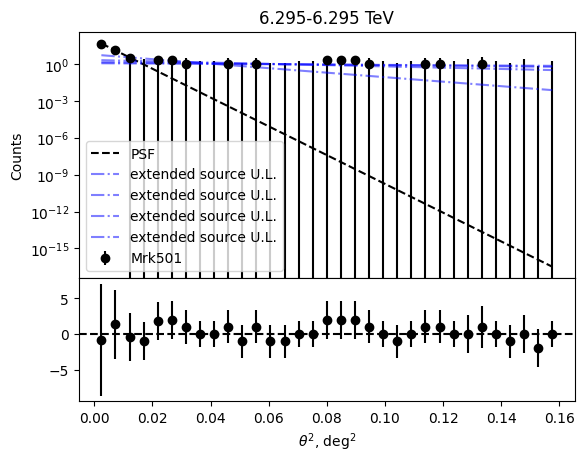

Best fit extended plus point gives chi2: 2.5505955833935063
Best fit extended plus point gives chi2: 2.571479198854302
Best fit extended plus point gives chi2: 2.5714791988542998
Best fit extended plus point gives chi2: 2.5714791988543175


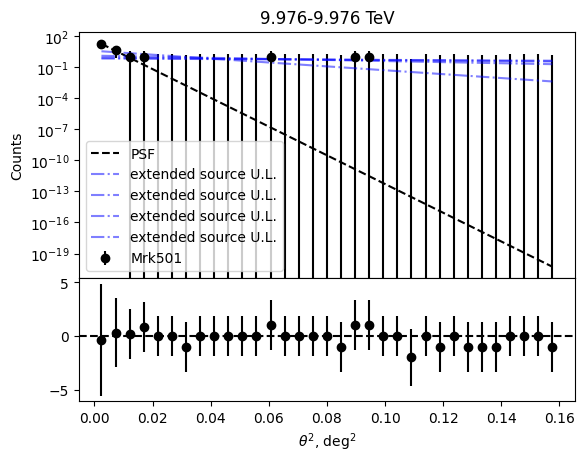

Best fit extended plus point gives chi2: 1.3295895675407863
Best fit extended plus point gives chi2: 1.330197869696018
Best fit extended plus point gives chi2: 1.34572089800543
Best fit extended plus point gives chi2: 1.3522344510787536


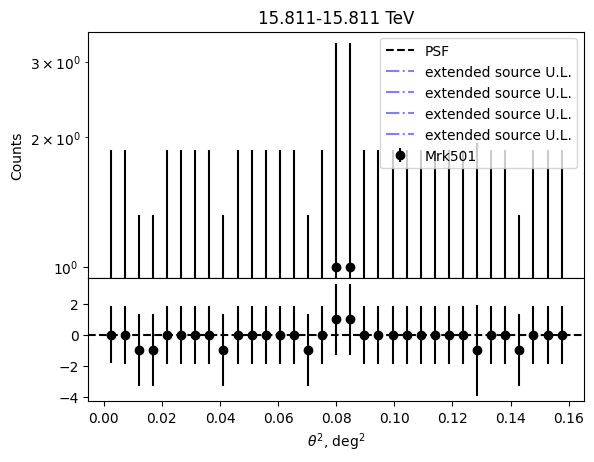

Best fit extended plus point gives chi2: 1.2973170178629263
Best fit extended plus point gives chi2: 1.2971630792889894
Best fit extended plus point gives chi2: 1.296082324404767
Best fit extended plus point gives chi2: 1.2951573307437798


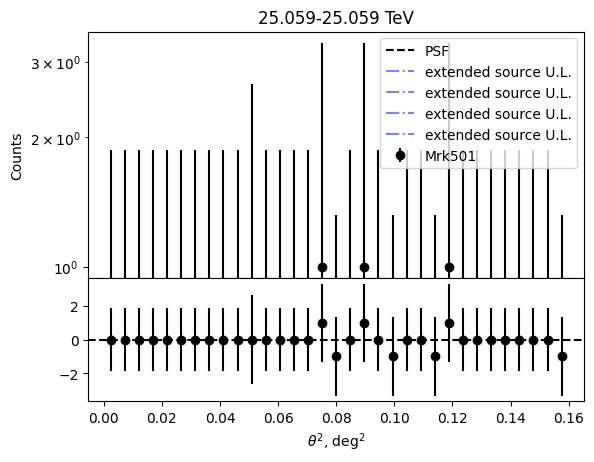

Best fit extended plus point gives chi2: 1.3073651003554723
Best fit extended plus point gives chi2: 1.3073651003554736
Best fit extended plus point gives chi2: 1.3066861563549308
Best fit extended plus point gives chi2: 1.3041911945653488


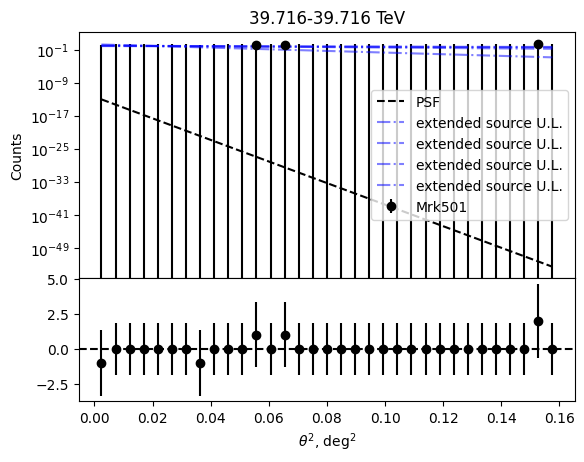

Best fit extended plus point gives chi2: 33.1237152487034
Best fit extended plus point gives chi2: 33.12371524870259
Best fit extended plus point gives chi2: 33.12371524870267
Best fit extended plus point gives chi2: 33.12371524870271


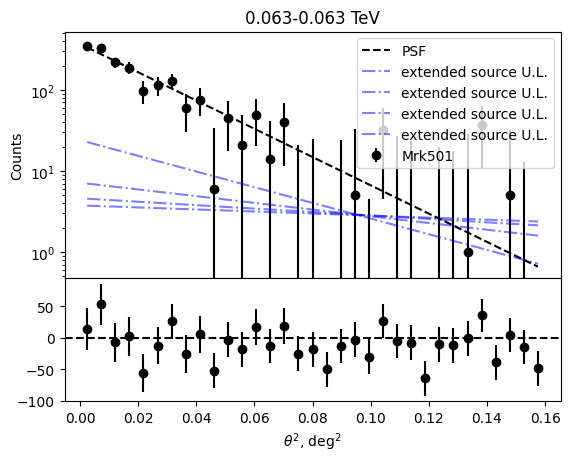

Best fit extended plus point gives chi2: 21.190501714332946
Best fit extended plus point gives chi2: 21.431687494607434
Best fit extended plus point gives chi2: 21.93815759407451
Best fit extended plus point gives chi2: 22.187133769749796


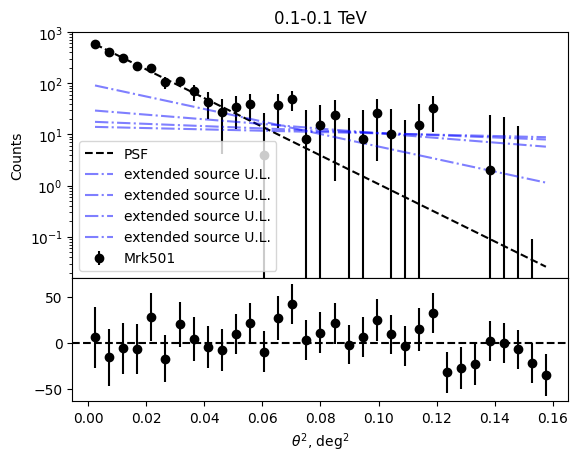

Best fit extended plus point gives chi2: 25.394629845199788
Best fit extended plus point gives chi2: 25.422082229800065
Best fit extended plus point gives chi2: 25.422082229800417
Best fit extended plus point gives chi2: 25.422082229799987


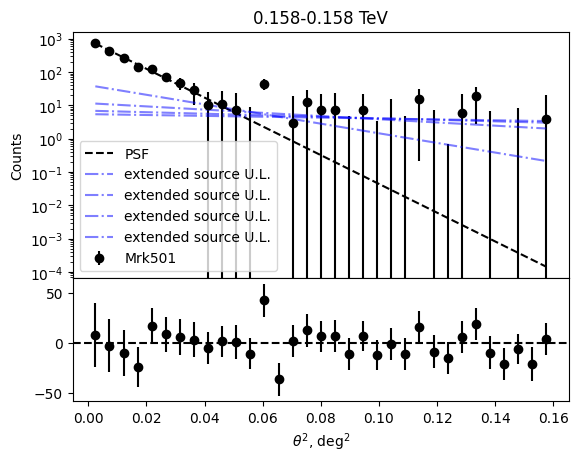

Best fit extended plus point gives chi2: 16.097730583948035
Best fit extended plus point gives chi2: 16.201753832411484
Best fit extended plus point gives chi2: 16.203010657284324
Best fit extended plus point gives chi2: 16.19997748190523


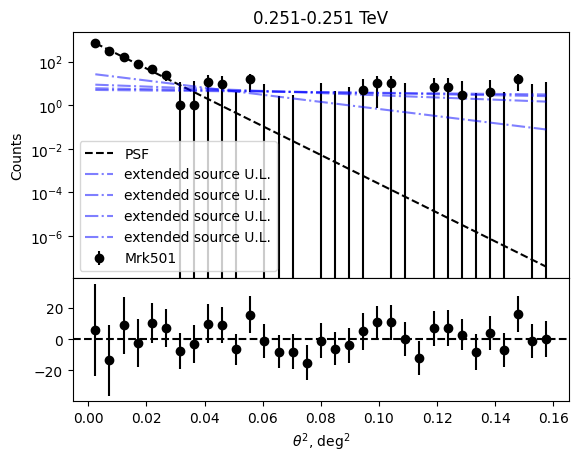

Best fit extended plus point gives chi2: 24.412480854184007
Best fit extended plus point gives chi2: 24.412480854184295
Best fit extended plus point gives chi2: 24.412480854184214
Best fit extended plus point gives chi2: 24.41248085418399


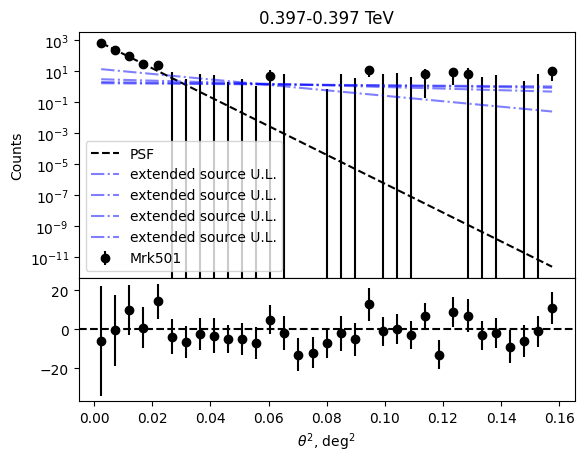

Best fit extended plus point gives chi2: 20.092982536505755
Best fit extended plus point gives chi2: 19.729978271783267
Best fit extended plus point gives chi2: 19.44484851412617
Best fit extended plus point gives chi2: 19.37045217201422


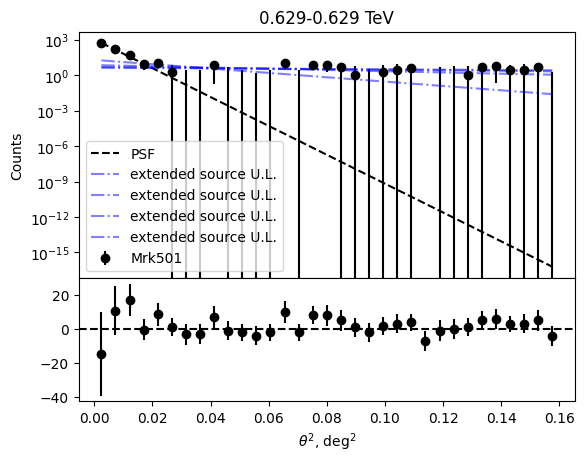

Best fit extended plus point gives chi2: 14.73539472849393
Best fit extended plus point gives chi2: 14.918656706855069
Best fit extended plus point gives chi2: 15.034162059776166
Best fit extended plus point gives chi2: 15.063291540589624


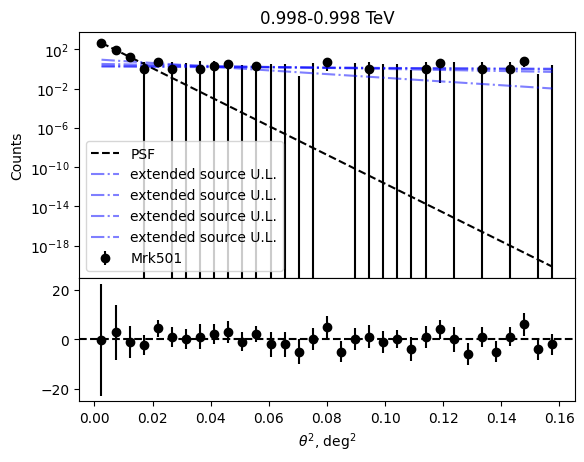

Best fit extended plus point gives chi2: 9.565730714925605
Best fit extended plus point gives chi2: 9.81593138093441
Best fit extended plus point gives chi2: 10.093814318241296
Best fit extended plus point gives chi2: 10.218112154194106


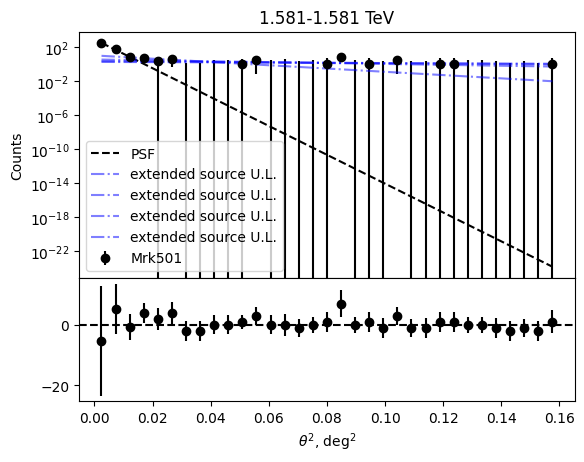

Best fit extended plus point gives chi2: 5.3557641711644335
Best fit extended plus point gives chi2: 6.16522358677799
Best fit extended plus point gives chi2: 6.297097052593782
Best fit extended plus point gives chi2: 6.298875610717885


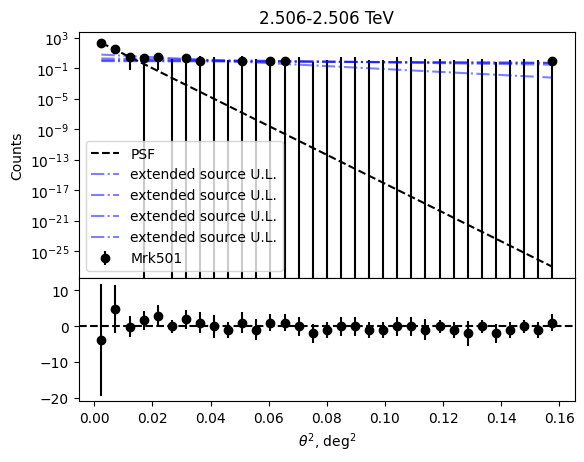

Best fit extended plus point gives chi2: 3.672950805901151
Best fit extended plus point gives chi2: 3.672950805901179
Best fit extended plus point gives chi2: 3.6729508059011704
Best fit extended plus point gives chi2: 3.6729508059011686


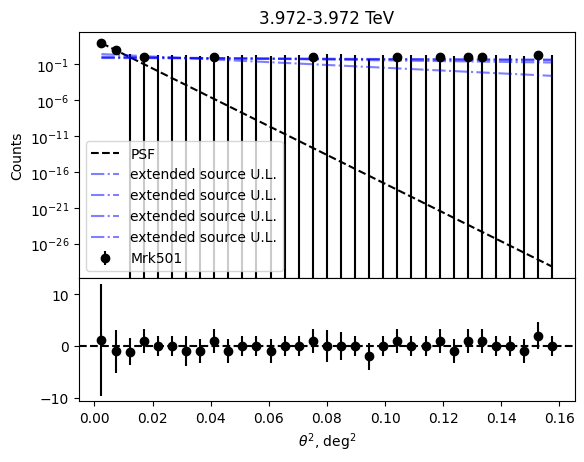

Best fit extended plus point gives chi2: 2.5842801773599295
Best fit extended plus point gives chi2: 2.584280177359907
Best fit extended plus point gives chi2: 2.584280177359931
Best fit extended plus point gives chi2: 2.584280177359921


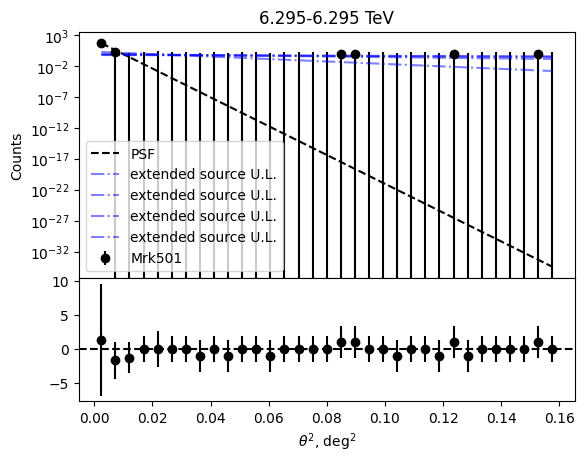

Best fit extended plus point gives chi2: 1.3379619593541208
Best fit extended plus point gives chi2: 1.3084593649403784
Best fit extended plus point gives chi2: 1.2727414717482364
Best fit extended plus point gives chi2: 1.2550114119270455


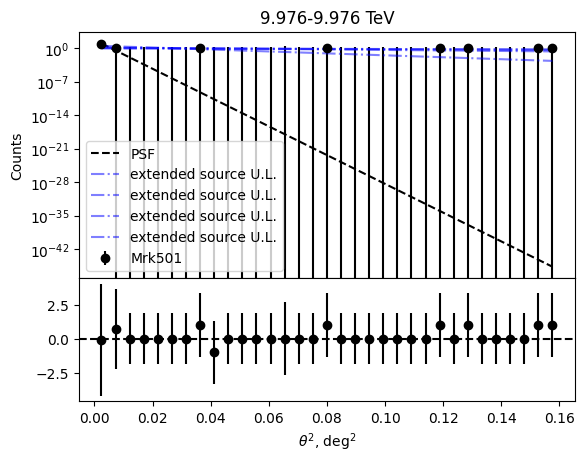

Best fit extended plus point gives chi2: 1.1224458036767313
Best fit extended plus point gives chi2: 1.1209164565823828
Best fit extended plus point gives chi2: 1.1128921400068807
Best fit extended plus point gives chi2: 1.107516023462112


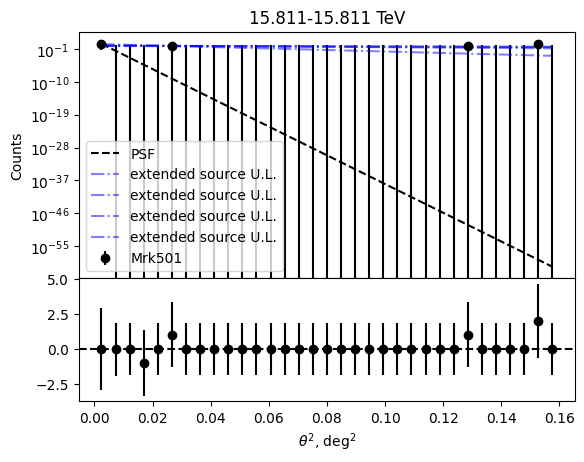

Best fit extended plus point gives chi2: 0.3706620051036779


/tmp/ipykernel_840/2711812904.py:128: RuntimeWarning: invalid value encountered in multiply
  ct_ext = ct_ext_best*adjust_ext


Best fit extended plus point gives chi2: 0.3706620051036779
Best fit extended plus point gives chi2: 0.3706620051036779
Best fit extended plus point gives chi2: 0.3706620051036779


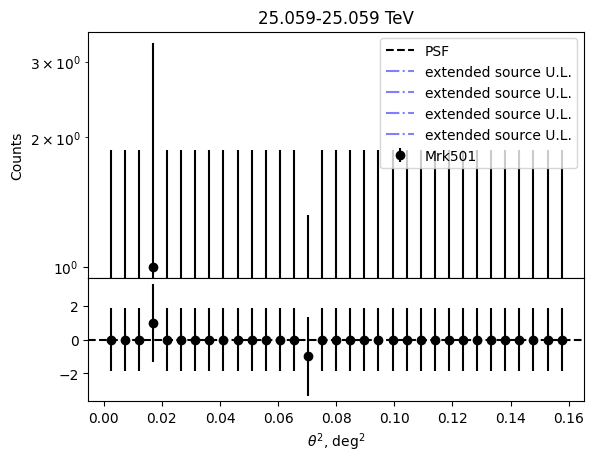

Best fit extended plus point gives chi2: 1.678027105459083


/tmp/ipykernel_840/2711812904.py:136: RuntimeWarning: invalid value encountered in multiply
  chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
/tmp/ipykernel_840/2711812904.py:148: RuntimeWarning: invalid value encountered in scalar divide
  flux_ratios[k][i] = np.sum(ct_ext)/cts_tot_best


Best fit extended plus point gives chi2: 1.678027105459083
Best fit extended plus point gives chi2: 1.678027105459083
Best fit extended plus point gives chi2: 1.678027105459083


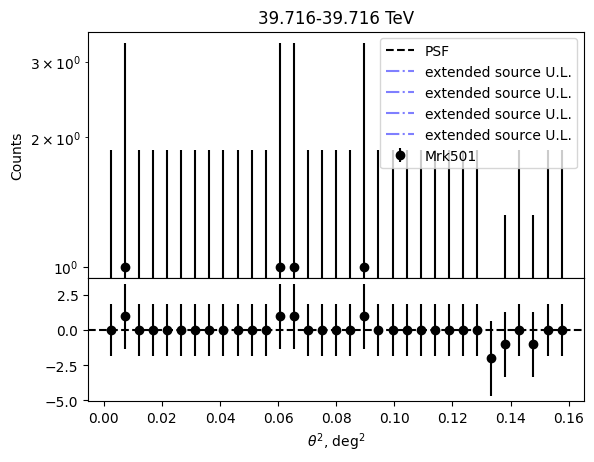

In [11]:
flux_ratios_40deg = calculate_UL(cts_40deg, cts_err_40deg, psf_hbu_40deg)
flux_ratios_20deg = calculate_UL(cts_20deg, cts_err_20deg, psf_hbu_20deg)

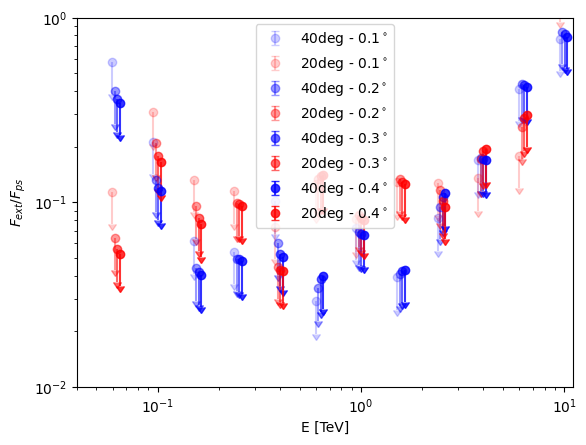

In [12]:
for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01, 1)
plt.legend()

In [13]:
def calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    th2_extended = np.concatenate([th2, th2])
    
    for i, ((ct_40deg, ct_err_40deg), (ct_20deg, ct_err_20deg)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
        ct = np.concatenate([ct_40deg, ct_20deg])
        ct_err = np.concatenate([ct_err_40deg, ct_err_20deg])
        ct_err += 0.0000001
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1_40deg, sigma_2_40deg, sigma_3_40deg, scale_40deg, ampl_2_40deg, ampl_3_40deg = psf_hbu_40deg.data[psf_index][0]
        sigma_1_20deg, sigma_2_20deg, sigma_3_20deg, scale_20deg, ampl_2_20deg, ampl_3_20deg = psf_hbu_20deg.data[psf_index][0]
        
        # Normalization of the PSF model to fit best the blazar
        def psf_model_40deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_40deg**2))
            gauss2 = ampl_2_40deg * np.exp(-th2 / (2 * sigma_2_40deg**2))
            gauss3 = ampl_3_40deg * np.exp(-th2 / (2 * sigma_3_40deg**2))
            return scale_40deg*(gauss1 + gauss2 + gauss3)
         
        def psf_model_20deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_20deg**2))
            gauss2 = ampl_2_20deg * np.exp(-th2 / (2 * sigma_2_20deg**2))
            gauss3 = ampl_3_20deg * np.exp(-th2 / (2 * sigma_3_20deg**2))
            return scale_20deg*(gauss1 + gauss2 + gauss3)

        psf_component_40deg = psf_model_40deg(th2)
        psf_component_20deg = psf_model_20deg(th2)
        psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])

        # CHANGES FINISH FOR A WHILE
        
        # rescaling the psf component to match total counts of the data
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        # psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        psf_component_err = np.zeros_like(psf_component)
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2_extended,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2_extended,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2_extended,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2_extended,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            
            # CHANGES CONTINUE
            
            def ext_model_40deg(th2):
                sigma1_conv = np.sqrt(sigma_1_40deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_40deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_40deg**2 + sigma_ext**2)
                c1 = sigma_1/(sigma_1**2 + sigma_ext**2)
                c2 = ampl_2*sigma_2/(sigma_2**2 + sigma_ext**2)
                c3 = ampl_3*sigma_3/(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2_40deg * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3_40deg * np.exp(-th2 / (2 * sigma3_conv**2))
                return scale_40deg*(gauss1_conv + gauss2_conv + gauss3_conv)

            def ext_model_20deg(th2):
                sigma1_conv = np.sqrt(sigma_1_20deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_20deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_20deg**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2_20deg * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3_20deg * np.exp(-th2 / (2 * sigma3_conv**2))
                return scale_20deg*(gauss1_conv + gauss2_conv + gauss3_conv)

            ct_ext_40deg = ext_model_40deg(th2)
            ct_ext_20deg = ext_model_20deg(th2)
            
            ct_ext = np.concatenate([ct_ext_40deg, ct_ext_20deg])
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0].plot(th2_extended,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

Best fit extended plus point gives chi2: 54.00313083012334
Best fit extended plus point gives chi2: 54.00313083012372
Best fit extended plus point gives chi2: 54.003130830125414
Best fit extended plus point gives chi2: 54.00313083012399


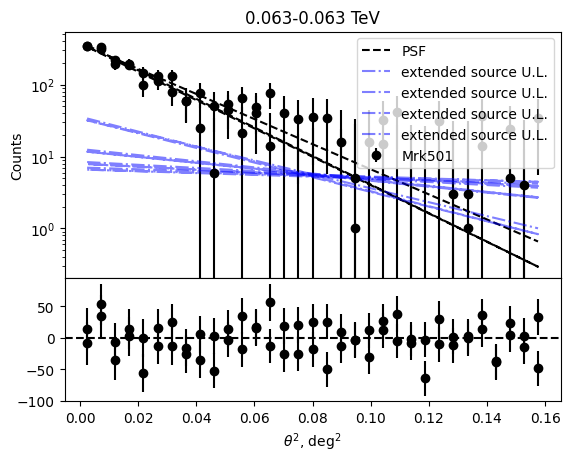

Best fit extended plus point gives chi2: 43.98150038777839
Best fit extended plus point gives chi2: 44.36940744093063
Best fit extended plus point gives chi2: 44.652575560152385
Best fit extended plus point gives chi2: 44.72871453527528


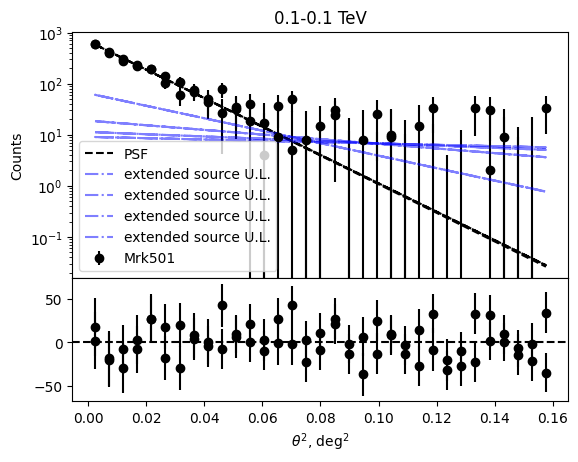

Best fit extended plus point gives chi2: 53.6767559450092
Best fit extended plus point gives chi2: 53.67675594501042
Best fit extended plus point gives chi2: 53.67675594500919
Best fit extended plus point gives chi2: 53.676755945009496


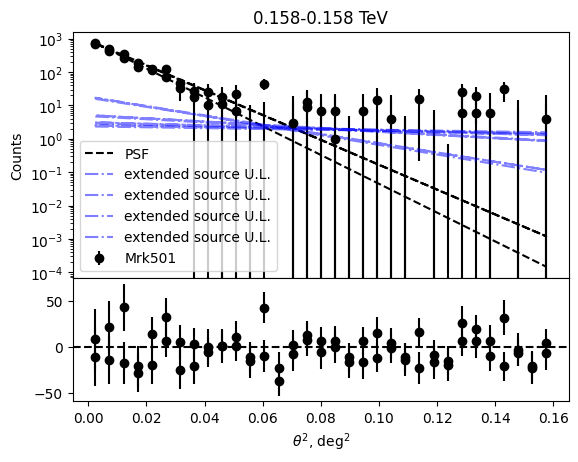

Best fit extended plus point gives chi2: 55.28852999368771
Best fit extended plus point gives chi2: 55.288529993687874
Best fit extended plus point gives chi2: 55.28852999368818
Best fit extended plus point gives chi2: 55.288529993687895


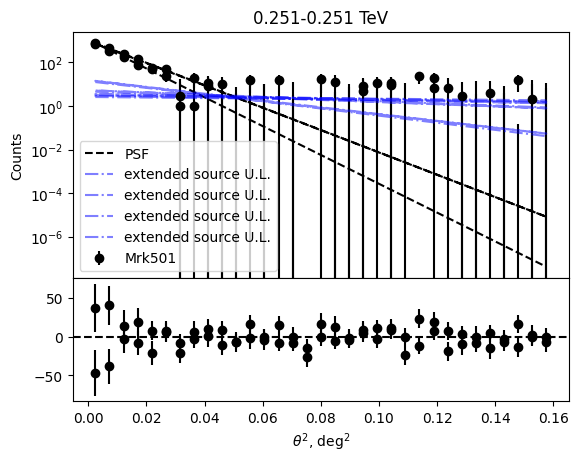

Best fit extended plus point gives chi2: 66.49065103851984
Best fit extended plus point gives chi2: 66.51547487184013
Best fit extended plus point gives chi2: 66.51547487183893
Best fit extended plus point gives chi2: 66.51547487184025


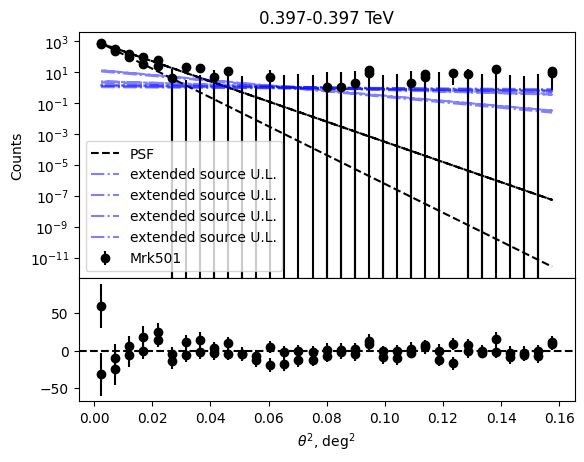

Best fit extended plus point gives chi2: 53.43081724803292
Best fit extended plus point gives chi2: 53.16672163112667
Best fit extended plus point gives chi2: 52.90333057520494
Best fit extended plus point gives chi2: 52.78780082790795


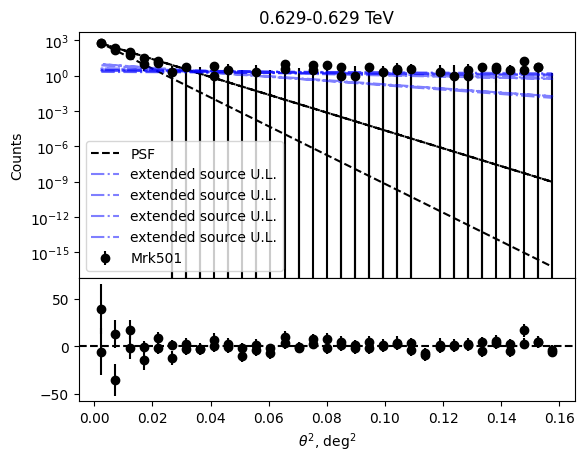

Best fit extended plus point gives chi2: 44.8149024112879
Best fit extended plus point gives chi2: 45.09204998308347
Best fit extended plus point gives chi2: 45.17587072943857
Best fit extended plus point gives chi2: 45.190208708577366


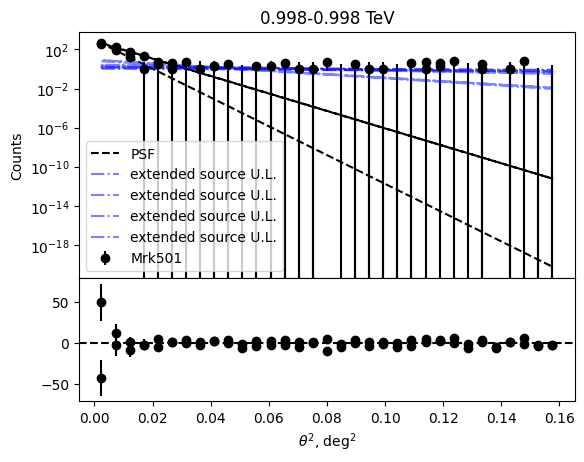

Best fit extended plus point gives chi2: 33.03104250670506
Best fit extended plus point gives chi2: 33.101749588838146
Best fit extended plus point gives chi2: 33.12535452908614
Best fit extended plus point gives chi2: 33.12779695008784


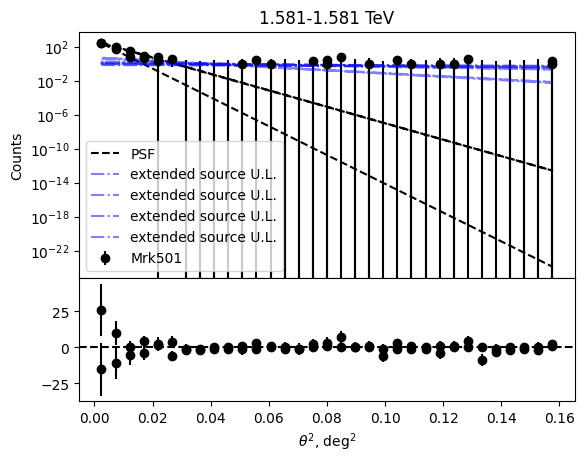

Best fit extended plus point gives chi2: 34.56585138546685
Best fit extended plus point gives chi2: 35.21628110469184
Best fit extended plus point gives chi2: 35.27609974645026
Best fit extended plus point gives chi2: 35.277151563699


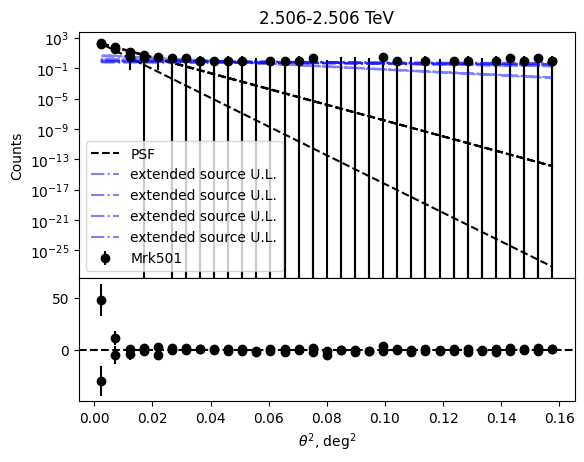

Best fit extended plus point gives chi2: 14.792705179410959
Best fit extended plus point gives chi2: 14.792705179410722
Best fit extended plus point gives chi2: 14.792705179410696
Best fit extended plus point gives chi2: 14.792705179410925


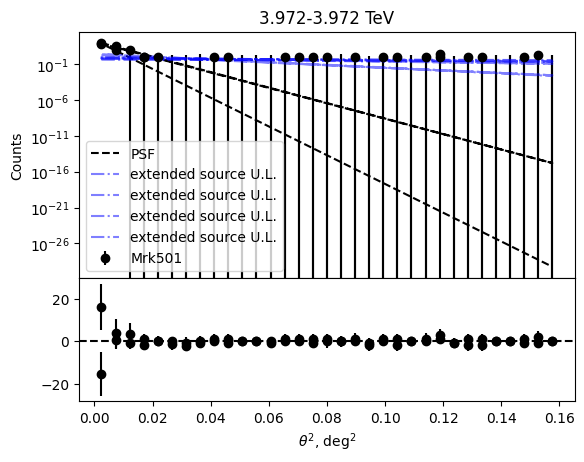

Best fit extended plus point gives chi2: 10.710606905693039
Best fit extended plus point gives chi2: 10.710606905693234
Best fit extended plus point gives chi2: 10.71025557662859
Best fit extended plus point gives chi2: 10.709331925041765


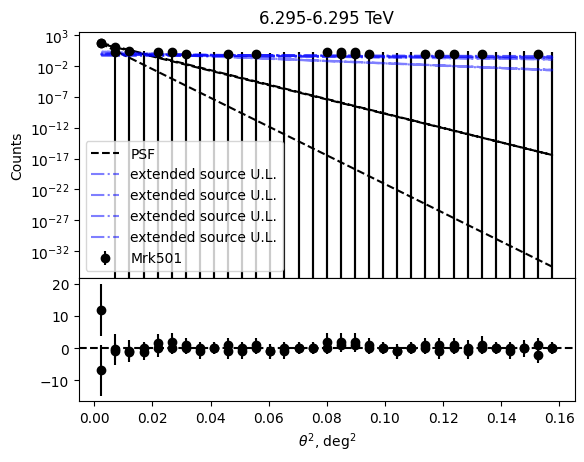

Best fit extended plus point gives chi2: 3.963947517029127
Best fit extended plus point gives chi2: 3.966976523317485
Best fit extended plus point gives chi2: 3.967656923000881
Best fit extended plus point gives chi2: 3.968227176591734


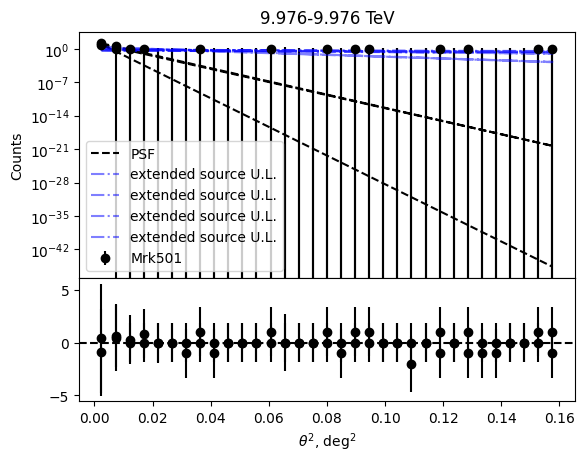

Best fit extended plus point gives chi2: 3.508516347210249
Best fit extended plus point gives chi2: 3.5091818437163296
Best fit extended plus point gives chi2: 3.5081939373561783
Best fit extended plus point gives chi2: 3.5069733217027093


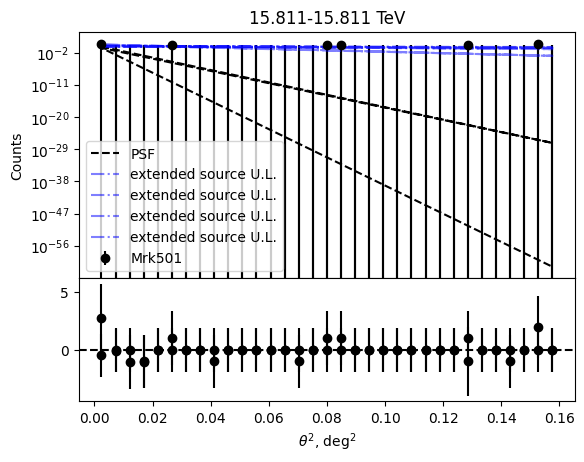

Best fit extended plus point gives chi2: 1.6679788793533261
Best fit extended plus point gives chi2: 1.667978879353325
Best fit extended plus point gives chi2: 1.6679776520060605
Best fit extended plus point gives chi2: 1.6677506366701575


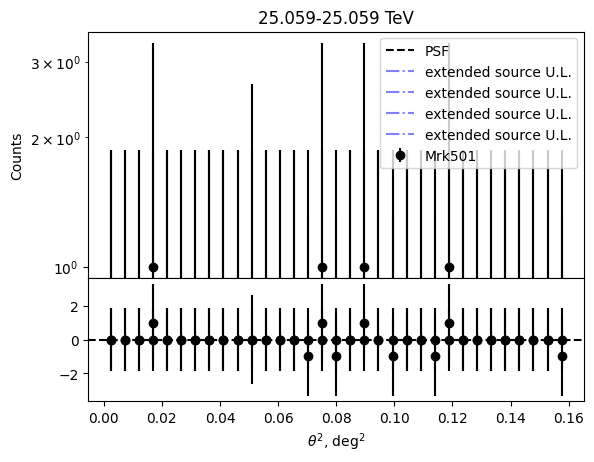

Best fit extended plus point gives chi2: 2.9838677641486346
Best fit extended plus point gives chi2: 2.968139333926155
Best fit extended plus point gives chi2: 2.9717427542829884
Best fit extended plus point gives chi2: 2.9748919587982425


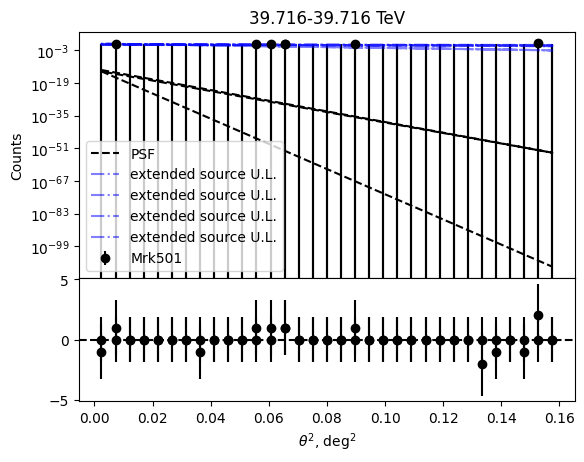

In [14]:
flux_ratios = calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg)

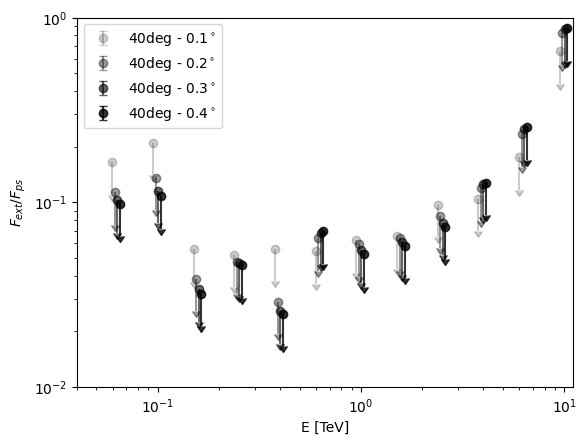

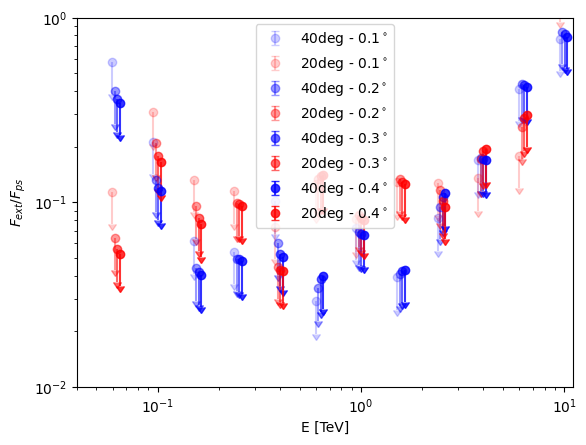

In [15]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01, 1)
plt.legend()
plt.show()

for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01, 1)
plt.legend()

In [16]:
flux_ratios

array([[1.65132040e-01, 2.10149972e-01, 5.58215129e-02, 5.20657330e-02,
        5.61439262e-02, 5.43947418e-02, 6.25239080e-02, 6.54563008e-02,
        9.71734524e-02, 1.04483606e-01, 1.75290988e-01, 6.55072113e-01,
        1.60863743e+01, 4.72886342e+07, 4.34310835e+01],
       [1.13140773e-01, 1.36063490e-01, 3.86287605e-02, 4.76057731e-02,
        2.89461583e-02, 6.37806386e-02, 5.92795954e-02, 6.37969821e-02,
        8.46951136e-02, 1.18912089e-01, 2.33926503e-01, 8.25184811e-01,
        3.09652047e+01, 8.67661108e+07, 1.35581343e+01],
       [1.02424866e-01, 1.15719200e-01, 3.39416471e-02, 4.66677513e-02,
        2.56882458e-02, 6.86575857e-02, 5.50444397e-02, 6.09379839e-02,
        7.74032818e-02, 1.24977801e-01, 2.50102342e-01, 8.64593305e-01,
        2.12499333e+01, 1.50040922e+03, 1.51263813e+01],
       [9.84282829e-02, 1.08213394e-01, 3.19745669e-02, 4.57482123e-02,
        2.49327583e-02, 6.99122054e-02, 5.25048623e-02, 5.80880902e-02,
        7.37564608e-02, 1.27489855e-0